In [1]:
pip install numpy matplotlib scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


--------------------------------------------------
Derived radar parameters
--------------------------------------------------
ADC capture time        : 51.200 us
Used bandwidth          : 3.072 GHz
Range resolution        : 0.04879 m/bin
Max unambiguous range   : 6.246 m
Search window           : 0.70 m to 1.40 m
Search bins             : 14 to 28
--------------------------------------------------

Loading \\wsl.localhost\Ubuntu-24.04\home\sisig\Dissertation-RobotAutomation\ros_jazzy_ws\src\my_bot_controller\normalBreath.bin ...
Data shape: (1500, 128, 256, 4)  (frames, chirps, samples, rx)

--------------------------------------------------
Best detection result
--------------------------------------------------
Best bin               : 21
Best distance          : 1.025 m
Best RX                : RX3
Peak breathing freq    : 0.200 Hz
Breathing rate         : 12.0 bpm
Peak magnitude         : 28.0180
Band median floor      : 4.9961
Confidence             : 5.61
Result status          

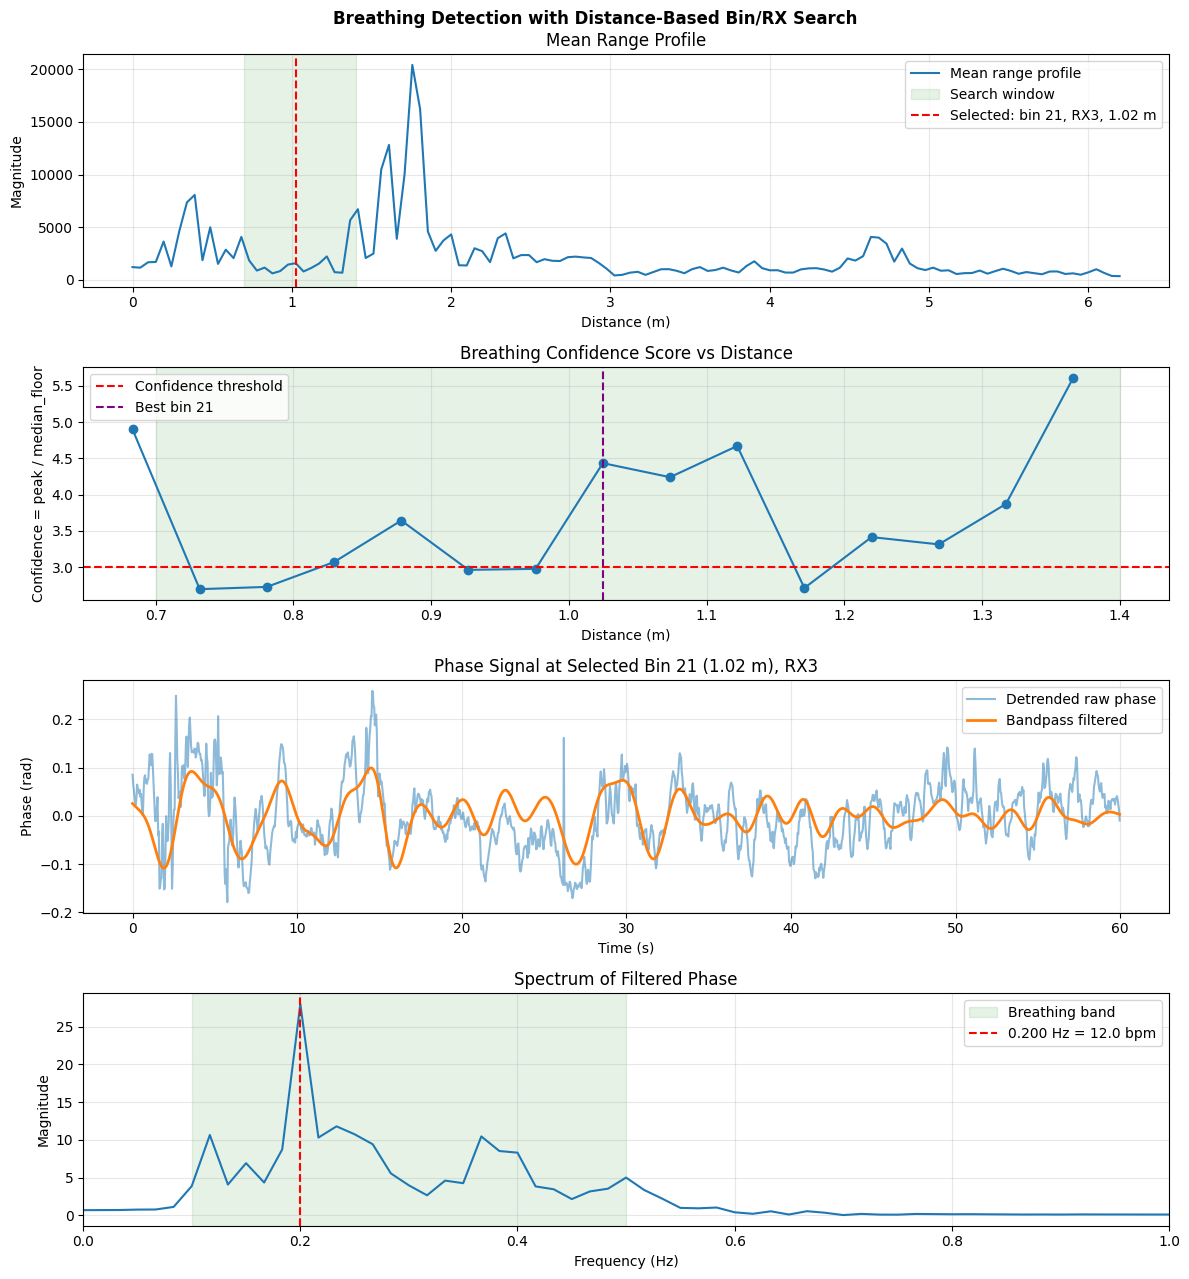

In [ ]:
#!/usr/bin/env python3

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, detrend

BIN_FILE = r'\\wsl.localhost\Ubuntu-24.04\home\sisig\Dissertation-RobotAutomation\ros_jazzy_ws\src\my_bot_controller\normalBreath.bin'
NUM_FRAMES        = 1500
CHIRPS_PER_FRAME  = 128
SAMPLES_PER_CHIRP = 256
NUM_RX            = 4
FRAME_RATE        = 25.0
BREATHE_LOW       = 0.10
BREATHE_HIGH      = 0.50
SEARCH_START_M    = 0.70
SEARCH_END_M      = 1.40
CONFIDENCE_THRESHOLD = 3.0

START_FREQ_GHZ    = 60.25
FREQ_SLOPE_MHZ_US = 60.0
ADC_START_US      = 6.0
ADC_SAMPLES       = 256
SAMPLE_RATE_KSPS  = 5000.0
RAMP_END_US       = 60.0
IDLE_TIME_US      = 100.0
# ------------------------------------------------------------------ #
# Derived radar parameters                                           #
# ------------------------------------------------------------------ #
c = 299792458.0
sample_rate_hz = SAMPLE_RATE_KSPS * 1e3
freq_slope_hz_s = FREQ_SLOPE_MHZ_US * 1e12
adc_capture_time_s = ADC_SAMPLES / sample_rate_hz
used_bandwidth_hz = freq_slope_hz_s * adc_capture_time_s
range_resolution_m = c / (2.0 * used_bandwidth_hz)
max_range_m = c * sample_rate_hz / (4.0 * freq_slope_hz_s)
num_range_bins = SAMPLES_PER_CHIRP // 2
range_axis_m = np.arange(num_range_bins) * range_resolution_m
search_start_bin = int(np.floor(SEARCH_START_M / range_resolution_m))
search_end_bin   = int(np.ceil(SEARCH_END_M / range_resolution_m))
search_start_bin = max(1, search_start_bin)
search_end_bin   = min(num_range_bins, search_end_bin)
print("--------------------------------------------------")
print("Derived radar parameters")
print("--------------------------------------------------")
print(f"ADC capture time        : {adc_capture_time_s * 1e6:.3f} us")
print(f"Used bandwidth          : {used_bandwidth_hz / 1e9:.3f} GHz")
print(f"Range resolution        : {range_resolution_m:.5f} m/bin")
print(f"Max unambiguous range   : {max_range_m:.3f} m")
print(f"Search window           : {SEARCH_START_M:.2f} m to {SEARCH_END_M:.2f} m")
print(f"Search bins             : {search_start_bin} to {search_end_bin - 1}")
print("--------------------------------------------------")
# ------------------------------------------------------------------ #
# Step 1: Load and reshape                                           #
# ------------------------------------------------------------------ #
print(f"\nLoading {BIN_FILE} ...")
raw = np.fromfile(BIN_FILE, dtype=np.int16)
expected = NUM_FRAMES * CHIRPS_PER_FRAME * SAMPLES_PER_CHIRP * NUM_RX * 2
if len(raw) != expected:
    raise ValueError(f"Expected {expected} int16 values, got {len(raw)}")
# [frames, chirps, samples, rx, 2(I/Q)]
raw = raw.reshape(NUM_FRAMES, CHIRPS_PER_FRAME, SAMPLES_PER_CHIRP, NUM_RX, 2)
data = raw[..., 0].astype(np.float32) + 1j * raw[..., 1].astype(np.float32)
print(f"Data shape: {data.shape}  (frames, chirps, samples, rx)")
# ------------------------------------------------------------------ #
# Step 2: Range FFT                                                  #
# ------------------------------------------------------------------ #
window = np.hanning(SAMPLES_PER_CHIRP).astype(np.float32).reshape(1, 1, -1, 1)
data_win = data * window
range_fft = np.fft.fft(data_win, axis=2)
range_fft = range_fft[:, :, :num_range_bins, :]  # keep positive range bins only
# Mean magnitude profile for display and initial sanity check
range_profile = np.mean(np.abs(range_fft), axis=(1, 3))   # [frames, bins]
mean_range_profile = np.mean(range_profile, axis=0)
# ------------------------------------------------------------------ #
# Step 3: Precompute filter and frequency axis                       #
# ------------------------------------------------------------------ #
nyq = FRAME_RATE / 2.0
low = BREATHE_LOW / nyq
high = BREATHE_HIGH / nyq
b_bp, a_bp = butter(4, [low, high], btype='band')
freqs = np.fft.rfftfreq(NUM_FRAMES, d=1.0 / FRAME_RATE)
band_mask = (freqs >= BREATHE_LOW) & (freqs <= BREATHE_HIGH)
# ------------------------------------------------------------------ #
# Step 4: Search all candidate bins and all RXs                      #
# ------------------------------------------------------------------ #
best_bin = None
best_rx = None
best_confidence = -np.inf
best_peak = None
best_floor = None
best_peak_freq = None
best_phase = None
best_filtered = None
best_spectrum = None
score_per_bin = np.full(num_range_bins, np.nan, dtype=np.float32)
best_rx_per_bin = np.full(num_range_bins, -1, dtype=np.int32)
for rb in range(search_start_bin, search_end_bin):
    best_conf_this_bin = -np.inf
    best_rx_this_bin = None
    for rx in range(NUM_RX):
        # average over chirps only
        slow_time_complex = np.mean(range_fft[:, :, rb, rx], axis=1)
        # unwrap phase and remove trends
        phase_signal = np.unwrap(np.angle(slow_time_complex))
        phase_signal = detrend(phase_signal, type='linear')
        phase_signal = phase_signal - np.mean(phase_signal)
        try:
            filtered = filtfilt(b_bp, a_bp, phase_signal)
        except ValueError:
            continue
        spectrum = np.abs(np.fft.rfft(filtered))
        band_spec = spectrum[band_mask]
        if len(band_spec) == 0:
            continue
        peak = np.max(band_spec)
        floor = np.median(band_spec) + 1e-12
        confidence = peak / floor
        if confidence > best_conf_this_bin:
            best_conf_this_bin = confidence
            best_rx_this_bin = rx
            peak_freq_this = freqs[band_mask][np.argmax(band_spec)]
            phase_this = phase_signal
            filtered_this = filtered
            spectrum_this = spectrum
            peak_this = peak
            floor_this = floor
    if best_rx_this_bin is not None:
        score_per_bin[rb] = best_conf_this_bin
        best_rx_per_bin[rb] = best_rx_this_bin
        if best_conf_this_bin > best_confidence:
            best_confidence = best_conf_this_bin
            best_bin = 21
            best_rx = best_rx_this_bin
            best_peak_freq = peak_freq_this
            best_phase = phase_this
            best_filtered = filtered_this
            best_spectrum = spectrum_this
            best_peak = peak_this
            best_floor = floor_this
# ------------------------------------------------------------------ #
# Step 5: Decide if detection is reliable                            #
# ------------------------------------------------------------------ #
if best_bin is None:
    print("\nNo candidate bin/RX pair found.")
    reliable = False
else:
    best_distance_m = best_bin * range_resolution_m
    breathing_rate_bpm = best_peak_freq * 60.0
    reliable = best_confidence >= CONFIDENCE_THRESHOLD
    print("\n--------------------------------------------------")
    print("Best detection result")
    print("--------------------------------------------------")
    print(f"Best bin               : {best_bin}")
    print(f"Best distance          : {best_distance_m:.3f} m")
    print(f"Best RX                : RX{best_rx}")
    print(f"Peak breathing freq    : {best_peak_freq:.3f} Hz")
    print(f"Breathing rate         : {breathing_rate_bpm:.1f} bpm")
    print(f"Peak magnitude         : {best_peak:.4f}")
    print(f"Band median floor      : {best_floor:.4f}")
    print(f"Confidence             : {best_confidence:.2f}")
    if reliable:
        print("Result status           : RELIABLE")
    else:
        print("Result status           : UNRELIABLE (confidence below threshold)")
    print("--------------------------------------------------")
# ------------------------------------------------------------------ #
# Step 6: Plot                                                       #
# ------------------------------------------------------------------ #
out_dir = os.path.dirname(BIN_FILE)
if out_dir == "":
    out_dir = "."
fig, axes = plt.subplots(4, 1, figsize=(12, 13))
fig.suptitle('Breathing Detection with Distance-Based Bin/RX Search', fontweight='bold')
# Plot 1: Mean range profile
axes[0].plot(range_axis_m, mean_range_profile, label='Mean range profile')
axes[0].axvspan(SEARCH_START_M, SEARCH_END_M, color='green', alpha=0.10, label='Search window')
if best_bin is not None:
    axes[0].axvline(best_bin * range_resolution_m, color='red', linestyle='--',
                    label=f'Selected: bin {best_bin}, RX{best_rx}, {best_bin * range_resolution_m:.2f} m')
axes[0].set_title('Mean Range Profile')
axes[0].set_xlabel('Distance (m)')
axes[0].set_ylabel('Magnitude')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
# Plot 2: Confidence score vs distance
valid = ~np.isnan(score_per_bin)
axes[1].plot(range_axis_m[valid], score_per_bin[valid], marker='o')
axes[1].axhline(CONFIDENCE_THRESHOLD, color='red', linestyle='--', label='Confidence threshold')
axes[1].axvspan(SEARCH_START_M, SEARCH_END_M, color='green', alpha=0.10)
if best_bin is not None:
    axes[1].axvline(best_bin * range_resolution_m, color='purple', linestyle='--',
                    label=f'Best bin {best_bin}')
axes[1].set_title('Breathing Confidence Score vs Distance')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Confidence = peak / median_floor')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
# Plot 3: Raw and filtered phase
if best_phase is not None and best_filtered is not None:
    time_axis = np.arange(NUM_FRAMES) / FRAME_RATE
    axes[2].plot(time_axis, best_phase, alpha=0.5, label='Detrended raw phase')
    axes[2].plot(time_axis, best_filtered, linewidth=2, label='Bandpass filtered')
    axes[2].set_title(f'Phase Signal at Selected Bin {best_bin} ({best_bin * range_resolution_m:.2f} m), RX{best_rx}')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('Phase (rad)')
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()
# Plot 4: Spectrum
if best_spectrum is not None:
    axes[3].plot(freqs, best_spectrum)
    axes[3].axvspan(BREATHE_LOW, BREATHE_HIGH, color='green', alpha=0.10, label='Breathing band')
    if best_peak_freq is not None:
        axes[3].axvline(best_peak_freq, color='red', linestyle='--',
                        label=f'{best_peak_freq:.3f} Hz = {best_peak_freq * 60.0:.1f} bpm')
    axes[3].set_title('Spectrum of Filtered Phase')
    axes[3].set_xlabel('Frequency (Hz)')
    axes[3].set_ylabel('Magnitude')
    axes[3].set_xlim(0, 1.0)
    axes[3].grid(True, alpha=0.3)
    axes[3].legend()
fig.tight_layout()
out_path = os.path.join(out_dir, 'breathing_detection_improved.png')
fig.savefig(out_path, bbox_inches='tight')
print(f"\nPlot saved -> {out_path}")
# ------------------------------------------------------------------ #
# Step 7: Final message                                              #
# ------------------------------------------------------------------ #
if best_bin is None:
    print("\nFINAL RESULT: No valid breathing estimate could be produced.")
elif reliable:
    print(f"\nFINAL RESULT: Breathing detected at {best_peak_freq * 60.0:.1f} bpm "
          f"(distance {best_bin * range_resolution_m:.2f} m, RX{best_rx}, confidence {best_confidence:.2f})")
else:
    print(f"\nFINAL RESULT: No reliable breathing estimate. "
          f"Best candidate was {best_peak_freq * 60.0:.1f} bpm "
          f"at {best_bin * range_resolution_m:.2f} m on RX{best_rx}, "
          f"but confidence was only {best_confidence:.2f}.")